In [1]:
### Installing dependencies
!pip install openai

!apt-get update
!apt-get install -y iverilog

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,143 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,226 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,6

In [2]:
verilog_generation_prompt = '''
RCA8 Natural Language Description

This design implements an 8-bit Ripple Carry Adder (RCA) using structural Verilog and gate-level primitives. Its purpose is to add two 8-bit input operands, a and b, and produce an 8-bit sum output together with a final carry-out bit, cout.

The design contains two modules: a reusable 1-bit Full Adder module named FA, and a top-level 8-bit module named RCA8. The FA module has five ports: inputs a, b, and cin, and outputs sum and cout. The RCA8 top-level module has two 8-bit inputs, a[7:0] and b[7:0], one 8-bit output sum[7:0], and one 1-bit output cout.

Inside the FA module, the sum output is computed in two XOR stages. First, a and b are XORed to generate an intermediate signal w0. Then w0 is XORed with cin to produce sum. The carry-out logic is implemented using two AND gates and one OR gate. One AND gate computes w0 & cin, another computes a & b, and the OR of these two terms generates cout. This realizes the standard full-adder carry equation:
cout = (a & b) | (cin & (a ^ b)).

The RCA8 module connects eight full adders in series to form a ripple-carry structure. Internal carry signals are stored in the wire vector c[7:1]. The least significant stage, fa0, adds a[0] and b[0] with an initial carry-in of 0. Its carry-out becomes c[1]. The middle six stages are instantiated as an array of full adders, covering bits [6:1]. Each stage takes its carry-in from the previous stage and passes its carry-out to the next stage. The final stage, fa7, adds the most significant bits a[7] and b[7] using c[7] as carry-in and produces the final carry-out cout.

The signal flow proceeds from the least significant bit to the most significant bit. Each bit position computes its local sum immediately, but the correctness of each higher bit depends on the carry generated by the previous stage. Because the carry must propagate sequentially through the chain, this design is simple and compact but slower than more advanced adders for larger bit widths.

A notable design feature is that the implementation is fully structural rather than behavioral. It explicitly instantiates a full-adder building block and uses primitive logic gates inside the FA module. Another feature is the use of Verilog instance arrays for the middle six full-adder stages, which keeps the code concise while preserving the ripple-carry architecture.
'''

In [ ]:
from openai import OpenAI
import os
client = OpenAI(
    api_key = ""
)

completion = client.chat.completions.create(
  model = "gpt-4o-mini",
  messages=[{"role":"user","content":verilog_generation_prompt}],
  max_tokens=1024, # limits the maximum number of tokens (words or pieces of words) that the model will generate in its response.
  stream=False
)

print(completion.choices[0].message.content)

Sure! Below is a Verilog implementation of an 8-bit Ripple Carry Adder (RCA) as described in your natural language description. This implementation follows the structural design using gate-level primitives and includes both the Full Adder (FA) module and the top-level RCA8 module.

```verilog
// Full Adder Module
module FA (
    input a,        // First input bit
    input b,        // Second input bit
    input cin,      // Carry input
    output sum,     // Sum output
    output cout     // Carry output
);
    wire w0;        // Intermediate wire for sum calculation

    // Sum output: sum = a XOR b XOR cin
    assign w0 = a ^ b;
    assign sum = w0 ^ cin;

    // Carry output: cout = (a AND b) OR (cin AND (a XOR b))
    assign cout = (a & b) | (cin & w0);
endmodule

// 8-bit Ripple Carry Adder Module
module RCA8 (
    input [7:0] a,  // First 8-bit input
    input [7:0] b,  // Second 8-bit input
    output [7:0] sum, // 8-bit sum output
    output cout      // 1-bit carry out
);
   

In [7]:
output_verilog_code = '''
module FA (
    input a,        // First input bit
    input b,        // Second input bit
    input cin,      // Carry input
    output sum,     // Sum output
    output cout     // Carry output
);
    wire w0;        // Intermediate wire for sum calculation

    // Sum output: sum = a XOR b XOR cin
    assign w0 = a ^ b;
    assign sum = w0 ^ cin;

    // Carry output: cout = (a AND b) OR (cin AND (a XOR b))
    assign cout = (a & b) | (cin & w0);
endmodule

// 8-bit Ripple Carry Adder Module
module RCA8 (
    input [7:0] a,  // First 8-bit input
    input [7:0] b,  // Second 8-bit input
    output [7:0] sum, // 8-bit sum output
    output cout      // 1-bit carry out
);
    wire [7:0] c;   // Internal carry signals

    // Instantiate the 1st Full Adder
    FA fa0 (
        .a(a[0]),
        .b(b[0]),
        .cin(1'b0),     // Initial carry-in is 0
        .sum(sum[0]),
        .cout(c[1])     // Carry-out to the next stage
    );

    // Instantiate the 2nd to 7th Full Adders using a generate loop
    genvar i;
    generate
        for (i = 1; i < 7; i = i + 1) begin: full_adder_array
            FA faN (
                .a(a[i]),
                .b(b[i]),
                .cin(c[i]),    // Previous stage's carry-out
                .sum(sum[i]),
                .cout(c[i + 1]) // Carry-out to the next stage
            );
        end
    endgenerate

    // Instantiate the 8th Full Adder
    FA fa7 (
        .a(a[7]),
        .b(b[7]),
        .cin(c[7]),     // Carry from the 7th stage
        .sum(sum[7]),
        .cout(cout)     // Final carry-out
    );
endmodule
'''
filename = "RCA8/RCA8_generated.v"
# Write the extracted Verilog code to the file
with open(filename, "w") as f:
    f.write(output_verilog_code)

In [10]:
verilog_generation_prompt2 = '''
Based on the following natural language description, generate COMPLETE compilable Verilog code for the exact CLA8 architecture.

STRICT REQUIREMENTS:

1. Include ALL modules described, including:
   - PGGen module
   - CLA8 top-level module

2. Preserve EXACT module names:
   - PGGen
   - CLA8

3. Preserve EXACT signal names:
   - g[7:0]
   - p[7:0]
   - c[7:0]
   - e[35:0]
   - cin

4. Preserve the SAME carry-lookahead architecture exactly as described:
   - Explicitly compute c[0] through c[7]
   - Do NOT simplify or rewrite carry equations
   - Do NOT approximate carry logic
   - Keep each carry equation structurally expanded

5. Maintain the SAME hierarchical structure:
   - PGGen submodule instantiated 8 times
   - CLA8 top module computes carry and sum

6. Use STRUCTURAL Verilog only:
   - Use gate-level primitives (and, or, xor, buf)
   - Do NOT use behavioral simplifications
   - Do NOT use arithmetic operators like +

7. Sum outputs must follow:
   - sum[0] = p[0] XOR cin
   - sum[i] = p[i] XOR c[i-1]

8. Final carry-out must be:
   - cout = c[7]

9. Output FULL Verilog code only.
Do not include explanations.
Do not omit any carry equations.
Do not compress repeated carry terms.

Do not add cin as a module input.
cin must be declared as an internal wire and driven by `buf (cin, 0);`
Use the exact carry indexing convention of the original CLA8 design, where c[0] is the carry generated from bit 0 logic, not the external input carry itself.

Generate exact architecture replication, not alternative implementations.
'''

In [ ]:
from openai import OpenAI
import os
client = OpenAI(
    api_key = ""
)

completion = client.chat.completions.create(
  model = "gpt-4",
  messages=[{"role":"user","content":verilog_generation_prompt2}],
  max_tokens=1024, # limits the maximum number of tokens (words or pieces of words) that the model will generate in its response.
  stream=False
)

print(completion.choices[0].message.content)

Below is the required verilog code:

```verilog
module PGGen (
    input a,
    input b,
    output gen,
    output prop
);

    assign gen = a & b;
    assign prop = a ^ b;
endmodule

module CLA8 (
   input [7:0] a,
   input [7:0] b,
   output [7:0] sum,
   output cout
);
    wire        cin, g[7:0], p[7:0], e[35:0], c[7:0];
    generate
        genvar i;
        for(i=0; i<8; i=i+1)
            PGGen PGInst(.a(a[i]), .b(b[i]), .gen(g[i]), .prop(p[i]));
    endgenerate

    and (e[0],  p[0], g[0]);
    and (e[1],  p[1], g[1]);
    and (e[2],  p[2], g[2]);
    and (e[3],  p[3], g[3]);
    and (e[4],  p[4], g[4]);
    and (e[5],  p[5], g[5]);
    and (e[6],  p[6], g[6]);
    and (e[7],  p[7], g[7]);
    and (e[8],  p[1], p[0]);
    and (e[9],  p[2], p[1], p[0]);
    and (e[10], p[3], p[2], p[1], p[0]);
    and (e[11], p[4], p[3], p[2], p[1], p[0]); 
    and (e[12], p[5], p[4], p[3], p[2], p[1], p[0]);
    and (e[13], p[6], p[5], p[4], p[3], p[2], p[1], p[0]);
    and (e[14], p[7], p[6],

In [14]:
output_verilog_code = '''
module PGGen(
    input a,
    input b,
    output g,
    output p
);
    and a1(g, a, b);
    xor x1(p, a, b);
endmodule

module CLA8(
    input [7:0] a,
    input [7:0] b,
    output [7:0] sum,
    output cout
);
    wire [7:0] g;
    wire [7:0] p;
    wire [7:0] c;
    wire [35:0] e;
    wire cin;

    // Initialize cin to 0
    buf(cin, 1'b0);

    // PGGen instantiation
    PGGen pg0(a[0], b[0], g[0], p[0]);
    PGGen pg1(a[1], b[1], g[1], p[1]);
    PGGen pg2(a[2], b[2], g[2], p[2]);
    PGGen pg3(a[3], b[3], g[3], p[3]);
    PGGen pg4(a[4], b[4], g[4], p[4]);
    PGGen pg5(a[5], b[5], g[5], p[5]);
    PGGen pg6(a[6], b[6], g[6], p[6]);
    PGGen pg7(a[7], b[7], g[7], p[7]);

    // Carry logic
    and a2(e[0], p[0], cin);
    or o1(c[0], g[0], e[0]);

    and a3(e[1], p[1], g[0]);
    and a4(e[2], p[1], p[0], cin);
    or o2(c[1], g[1], e[1], e[2]);

    and a5(e[3], p[2], g[1]);
    and a6(e[4], p[2], p[1], g[0]);
    and a7(e[5], p[2], p[1], p[0], cin);
    or o3(c[2], g[2], e[3], e[4], e[5]);

    and a8(e[6], p[3], g[2]);
    and a9(e[7], p[3], p[2], g[1]);
    and a10(e[8], p[3], p[2], p[1], g[0]);
    and a11(e[9], p[3], p[2], p[1], p[0], cin);
    or o4(c[3], g[3], e[6], e[7], e[8], e[9]);

    and a12(e[10], p[4], g[3]);
    and a13(e[11], p[4], p[3], g[2]);
    and a14(e[12], p[4], p[3], p[2], g[1]);
    and a15(e[13], p[4], p[3], p[2], p[1], g[0]);
    and a16(e[14], p[4], p[3], p[2], p[1], p[0], cin);
    or o5(c[4], g[4], e[10], e[11], e[12], e[13], e[14]);

    and a17(e[15], p[5], g[4]);
    and a18(e[16], p[5], p[4], g[3]);
    and a19(e[17], p[5], p[4], p[3], g[2]);
    and a20(e[18], p[5], p[4], p[3], p[2], g[1]);
    and a21(e[19], p[5], p[4], p[3], p[2], p[1], g[0]);
    and a22(e[20], p[5], p[4], p[3], p[2], p[1], p[0], cin);
    or o6(c[5], g[5], e[15], e[16], e[17], e[18], e[19], e[20]);

    and a23(e[21], p[6], g[5]);
    and a24(e[22], p[6], p[5], g[4]);
    and a25(e[23], p[6], p[5], p[4], g[3]);
    and a26(e[24], p[6], p[5], p[4], p[3], g[2]);
    and a27(e[25], p[6], p[5], p[4], p[3], p[2], g[1]);
    and a28(e[26], p[6], p[5], p[4], p[3], p[2], p[1], g[0]);
    and a29(e[27], p[6], p[5], p[4], p[3], p[2], p[1], p[0], cin);
    or o7(c[6], g[6], e[21], e[22], e[23], e[24], e[25], e[26], e[27]);

    and a30(e[28], p[7], g[6]);
    and a31(e[29], p[7], p[6], g[5]);
    and a32(e[30], p[7], p[6], p[5], g[4]);
    and a33(e[31], p[7], p[6], p[5], p[4], g[3]);
    and a34(e[32], p[7], p[6], p[5], p[4], p[3], g[2]);
    and a35(e[33], p[7], p[6], p[5], p[4], p[3], p[2], g[1]);
    and a36(e[34], p[7], p[6], p[5], p[4], p[3], p[2], p[1], g[0]);
    and a37(e[35], p[7], p[6], p[5], p[4], p[3], p[2], p[1], p[0], cin);
    or o8(c[7], g[7], e[28], e[29], e[30], e[31], e[32], e[33], e[34], e[35]);

    // Sum calculations
    xor s0(sum[0], p[0], cin);
    xor s1(sum[1], p[1], c[0]);
    xor s2(sum[2], p[2], c[1]);
    xor s3(sum[3], p[3], c[2]);
    xor s4(sum[4], p[4], c[3]);
    xor s5(sum[5], p[5], c[4]);
    xor s6(sum[6], p[6], c[5]);
    xor s7(sum[7], p[7], c[6]);

    // Final carry-out
    assign cout = c[7];

endmodule
'''
filename = "CLA8/CLA8_generated.v"
# Write the extracted Verilog code to the file
with open(filename, "w") as f:
    f.write(output_verilog_code)

In [17]:
!iverilog -g2012 -o RCA8/RCA8_generated.vvp RCA8/RCA8_generated.v RCA8_tb.v && vvp RCA8/RCA8_generated.vvp

VCD info: dumpfile RCA8_tb.vcd opened for output.
--------------------------------------------------
TEST 1
a = 0x0 (00000000), b = 0x0 (00000000)
Expected: sum = 00000000, cout = 0, c = 0000000
Actual  : sum = 00000000, cout = 0, c = 0000000
Result  : PASS
--------------------------------------------------
TEST 2
a = 0x1 (00000001), b = 0x1 (00000001)
Expected: sum = 00000010, cout = 0, c = 0000001
Actual  : sum = 00000010, cout = 0, c = 0000001
Result  : PASS
--------------------------------------------------
TEST 3
a = 0xf (00001111), b = 0x1 (00000001)
Expected: sum = 00010000, cout = 0, c = 0001111
Actual  : sum = 00010000, cout = 0, c = 0001111
Result  : PASS
--------------------------------------------------
TEST 4
a = 0xff (11111111), b = 0x1 (00000001)
Expected: sum = 00000000, cout = 1, c = 1111111
Actual  : sum = 00000000, cout = 1, c = 1111111
Result  : PASS
--------------------------------------------------
TEST 5
a = 0xaa (10101010), b = 0x55 (01010101)
Expected: sum = 11

In [20]:
!iverilog -g2012 -o CLA8/CLA8_generated.vvp CLA8/CLA8_generated.v CLA8_tb.v && vvp CLA8/CLA8_generated.vvp

VCD info: dumpfile CLA8_tb.vcd opened for output.
--------------------------------------------------
TEST 1
a = 0x0 (00000000), b = 0x0 (00000000)
Expected: sum=00000000 cout=0 g=00000000 p=00000000 c=00000000
Actual  : sum=00000000 cout=0 g=00000000 p=00000000 c=00000000
Result  : PASS
--------------------------------------------------
TEST 2
a = 0x1 (00000001), b = 0x1 (00000001)
Expected: sum=00000010 cout=0 g=00000001 p=00000000 c=00000001
Actual  : sum=00000010 cout=0 g=00000001 p=00000000 c=00000001
Result  : PASS
--------------------------------------------------
TEST 3
a = 0xf (00001111), b = 0x1 (00000001)
Expected: sum=00010000 cout=0 g=00000001 p=00001110 c=00001111
Actual  : sum=00010000 cout=0 g=00000001 p=00001110 c=00001111
Result  : PASS
--------------------------------------------------
TEST 4
a = 0xff (11111111), b = 0x1 (00000001)
Expected: sum=00000000 cout=1 g=00000001 p=11111110 c=11111111
Actual  : sum=00000000 cout=1 g=00000001 p=11111110 c=11111111
Result  : PA

In [ ]:
!sudo apt-get update
!sudo apt-get install -y gtkwave

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Fetched 388 kB in 2s (217 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional 

In [ ]:
!gtkwave RCA8_tb.vcd

Could not initialize GTK!  Is DISPLAY env var/xhost set?

Usage: gtkwave [OPTION]... [DUMPFILE] [SAVEFILE] [RCFILE]

  -n, --nocli=DIRPATH        use file requester for dumpfile name
  -f, --dump=FILE            specify dumpfile name
  -F, --fastload             generate/use VCD recoder fastload files
  -o, --optimize             optimize VCD to FST
  -a, --save=FILE            specify savefile name
  -A, --autosavename         assume savefile is suffix modified dumpfile name
  -r, --rcfile=FILE          specify override .rcfile name
  -d, --defaultskip          if missing .rcfile, do not use useful defaults
  -D, --dualid=WHICH         specify multisession identifier
  -l, --logfile=FILE         specify simulation logfile name for time values
  -s, --start=TIME           specify start time for LXT2/VZT block skip
  -e, --end=TIME             specify end time for LXT2/VZT block skip
  -t, --stems=FILE           specify stems file for source code annotation
  -c, --cpu=NUMCPUS          

In [21]:
!zip -r adder_project.zip RCA8 CLA8 sample_data *.txt *.v *.vcd

  adding: RCA8/ (stored 0%)
  adding: RCA8/RCA8_generated.v (deflated 63%)
  adding: RCA8/RCA8_generated.vvp (deflated 85%)
  adding: RCA8/.ipynb_checkpoints/ (stored 0%)
  adding: CLA8/ (stored 0%)
  adding: CLA8/CLA8_generated.vvp (deflated 87%)
  adding: CLA8/CLA8_generated.v (deflated 73%)
  adding: sample_data/ (stored 0%)
  adding: sample_data/README.md (deflated 39%)
  adding: sample_data/anscombe.json (deflated 83%)
  adding: sample_data/mnist_train_small.csv (deflated 88%)
  adding: sample_data/california_housing_train.csv (deflated 79%)
  adding: sample_data/mnist_test.csv (deflated 88%)
  adding: sample_data/california_housing_test.csv (deflated 76%)
  adding: CLA8_description.txt (deflated 50%)
  adding: CLA8_verification_report.txt (deflated 60%)
  adding: RCA8_description.txt (deflated 55%)
  adding: RCA8_verification_report.txt (deflated 57%)
  adding: CLA8_tb.v (deflated 81%)
  adding: RCA8_tb.v (deflated 73%)
  adding: CLA8_tb.vcd (deflated 71%)
  adding: RCA8_tb.vcd (

In [23]:
!sudo apt-get update
!sudo apt-get install -y yosys

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 7,549 B in 2s (4,438 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will b

In [25]:
!wget https://raw.githubusercontent.com/The-OpenROAD-Project/OpenROAD-flow-scripts/master/flow/platforms/nangate45/lib/NangateOpenCellLibrary_typical.lib -O nangate45.lib

--2026-04-12 19:45:57--  https://raw.githubusercontent.com/The-OpenROAD-Project/OpenROAD-flow-scripts/master/flow/platforms/nangate45/lib/NangateOpenCellLibrary_typical.lib
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6692032 (6.4M) [text/plain]
Saving to: ‘nangate45.lib’

nangate45.lib       100%[===================>]   6.38M  --.-KB/s    in 0.07s   

2026-04-12 19:45:57 (94.8 MB/s) - ‘nangate45.lib’ saved [6692032/6692032]



In [26]:
!ls -lh nangate45.lib

-rw-r--r-- 1 root root 6.4M Apr 12 19:45 nangate45.lib


In [29]:
!yosys -V

Yosys 0.9 (git sha1 1979e0b)


In [30]:
!ls -lh nangate45.lib

-rw-r--r-- 1 root root 6.4M Apr 12 19:45 nangate45.lib


In [31]:
with open("constraints.sdc","w") as f:
    f.write("""create_clock -name clk -period 2.0
set_input_delay 0.2 -clock clk [all_inputs]
set_output_delay 0.2 -clock clk [all_outputs]
""")

In [32]:
with open("synth_adder.ys","w") as f:
    f.write("""read_verilog $env(ADDER_FILE)
hierarchy -check -top $env(TOP_MODULE)
proc; opt; fsm; opt; memory; opt
techmap; opt
dfflibmap -liberty nangate45.lib
abc -liberty nangate45.lib -constr constraints.sdc
clean
stat -liberty nangate45.lib
tee -o timing_report.txt sta
""")

In [33]:
code = '''
import subprocess, re, os, json

def synthesize(verilog_file, top_module, lib_file='nangate45.lib'):
    env = os.environ.copy()
    env['ADDER_FILE'] = verilog_file
    env['TOP_MODULE'] = top_module
    result = subprocess.run(
        ['yosys', '-s', 'synth_adder.ys'],
        capture_output=True, text=True, env=env)
    return parse_stats(result.stdout + result.stderr)

def parse_stats(log):
    ppa = {}

    m = re.search(r'Chip area for.*?:\\s+([\\d.]+)', log)
    ppa['area_um2'] = float(m.group(1)) if m else None

    m = re.search(r'Number of cells:\\s+(\\d+)', log)
    ppa['cell_count'] = int(m.group(1)) if m else None

    m = re.search(r'Longest topological path.*?\\((\\d+) levels?\\)', log)
    ppa['logic_levels'] = int(m.group(1)) if m else None

    return ppa

if __name__ == '__main__':
    import sys
    ppa = synthesize(sys.argv[1], sys.argv[2])
    print(json.dumps(ppa, indent=2))
'''
with open("run_yosys.py","w") as f:
    f.write(code)

In [62]:
!python run_yosys.py RCA8/RCA8_generated.v RCA8


 /----------------------------------------------------------------------------\
 |                                                                            |
 |  yosys -- Yosys Open SYnthesis Suite                                       |
 |                                                                            |
 |  Copyright (C) 2012 - 2019  Clifford Wolf <clifford@clifford.at>           |
 |                                                                            |
 |  Permission to use, copy, modify, and/or distribute this software for any  |
 |  purpose with or without fee is hereby granted, provided that the above    |
 |  copyright notice and this permission notice appear in all copies.         |
 |                                                                            |
 |  THE SOFTWARE IS PROVIDED "AS IS" AND THE AUTHOR DISCLAIMS ALL WARRANTIES  |
 |  WITH REGARD TO THIS SOFTWARE INCLUDING ALL IMPLIED WARRANTIES OF          |
 |  MERCHANTABILITY AND FITNESS. IN NO 

In [70]:
import subprocess
import re
import os
import json
import subprocess, re, os, json

def parse_stats(log):
    ppa = {}

    m = re.search(r'Chip area for module .*?:\s+([\d.]+)', log)
    ppa['area_um2'] = float(m.group(1)) if m else None

    m = re.search(r'Number of cells:\s+(\d+)', log)
    ppa['cell_count'] = int(m.group(1)) if m else None

    m = re.search(r'Longest topological path.*?\((\d+) levels?\)', log)
    ppa['logic_levels'] = int(m.group(1)) if m else None

    return ppa

if __name__ == '__main__':
    import sys
    env = os.environ.copy()
    env['ADDER_FILE'] = sys.argv[1]
    env['TOP_MODULE'] = sys.argv[2]

    result = subprocess.run(
        ['yosys', '-s', 'synth_adder.ys'],
        capture_output=True, text=True, env=env
    )

    ppa = parse_stats(result.stdout + result.stderr)
    print(json.dumps(ppa, indent=2))

if __name__ == '__main__':
    import sys
    env = os.environ.copy()
    env['ADDER_FILE'] = sys.argv[1]
    env['TOP_MODULE'] = sys.argv[2]

    result = subprocess.run(
        ['yosys', '-s', 'synth_adder.ys'],
        capture_output=True, text=True, env=env
    )

    print("===== STDOUT =====")
    print(result.stdout)
    print("===== STDERR =====")
    print(result.stderr)

    ppa = parse_stats(result.stdout + result.stderr)
    print(json.dumps(ppa, indent=2))

{
  "area_um2": 44.954,
  "cell_count": 37,
  "logic_levels": null
}
===== STDOUT =====

 /----------------------------------------------------------------------------\
 |                                                                            |
 |  yosys -- Yosys Open SYnthesis Suite                                       |
 |                                                                            |
 |  Copyright (C) 2012 - 2019  Clifford Wolf <clifford@clifford.at>           |
 |                                                                            |
 |  Permission to use, copy, modify, and/or distribute this software for any  |
 |  purpose with or without fee is hereby granted, provided that the above    |
 |  copyright notice and this permission notice appear in all copies.         |
 |                                                                            |
 |  THE SOFTWARE IS PROVIDED "AS IS" AND THE AUTHOR DISCLAIMS ALL WARRANTIES  |
 |  WITH REGARD TO THIS SOFTWAR

In [36]:
!ls -lh nangate45.lib

-rw-r--r-- 1 root root 6.4M Apr 12 19:45 nangate45.lib


In [79]:
!python run_yosys.py RCA8/RCA8_generated.v RCA8


 /----------------------------------------------------------------------------\
 |                                                                            |
 |  yosys -- Yosys Open SYnthesis Suite                                       |
 |                                                                            |
 |  Copyright (C) 2012 - 2019  Clifford Wolf <clifford@clifford.at>           |
 |                                                                            |
 |  Permission to use, copy, modify, and/or distribute this software for any  |
 |  purpose with or without fee is hereby granted, provided that the above    |
 |  copyright notice and this permission notice appear in all copies.         |
 |                                                                            |
 |  THE SOFTWARE IS PROVIDED "AS IS" AND THE AUTHOR DISCLAIMS ALL WARRANTIES  |
 |  WITH REGARD TO THIS SOFTWARE INCLUDING ALL IMPLIED WARRANTIES OF          |
 |  MERCHANTABILITY AND FITNESS. IN NO 

In [86]:
import json
import os
import importlib
from openai import OpenAI
import run_yosys

# 先重载，避免 notebook 继续用旧版 run_yosys
importlib.reload(run_yosys)

# 不要把真实 key 写进代码文件。
# 在 notebook 里先单独执行:
# os.environ["OPENAI_API_KEY"] = "你的新key"
api_key = os.getenv("OPENAI_API_KEY", "").strip()
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set. Please set a valid key before running.")

client = OpenAI(api_key=api_key)

SYSTEM_PROMPT = """You are an expert digital circuit designer.
Your goal is to generate synthesizable Verilog for an 8-bit adder
that minimizes area (cell_count) while keeping critical-path delay low.

Respond with ONLY valid synthesizable Verilog code.
No markdown fences.
No commentary.

Hard constraints:
1. Keep top module name exactly RCA8.
2. Keep same I/O interface as baseline.
3. Must synthesize successfully in Yosys.
"""

DELAY_TARGET_PS = 300


def llm_generate(history):
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "system", "content": SYSTEM_PROMPT}] + history,
        temperature=0.2,
    )
    return response.choices[0].message.content.strip()


def build_feedback_prompt(iteration, ppa, prev_code, best_ppa):
    return f"""Iteration {iteration} synthesis results:

Current candidate:
- cell_count: {ppa['cell_count']}
- delay_ps: {ppa['logic_levels']}
- area_um2: {ppa['area_um2']}

Best so far:
- cell_count: {best_ppa['cell_count']}
- delay_ps: {best_ppa['logic_levels']}
- area_um2: {best_ppa['area_um2']}

Propose a new 8-bit adder Verilog implementation that reduces cell count
while keeping delay_ps <= {DELAY_TARGET_PS}.

Try architectural alternatives such as:
- hybrid CLA + RCA
- carry select grouping
- Brent-Kung style prefix tree
- partial prefix carry logic

Provide ONLY Verilog code.
"""


def run_loop(baseline_verilog, top="RCA8", max_iter=10):
    history = []

    best_ppa = {
        "cell_count": 10**9,
        "logic_levels": 10**9,
        "area_um2": 10**9,
    }

    best_code = baseline_verilog
    results = []

    history.append({
        "role": "user",
        "content":
            f"Here is an 8-bit adder baseline:\n{baseline_verilog}\n"
            "Start from this design. Your first proposal may be identical."
    })

    for i in range(1, max_iter + 1):
        print(f"\n=== Iteration {i} ===")

        verilog = llm_generate(history)

        fname = f"candidate_{i}.v"
        with open(fname, "w", encoding="utf-8") as f:
            f.write(verilog)

        try:
            ppa = run_yosys.synthesize(fname, top)
        except Exception as e:
            print(f"Synthesis failed: {e}")

            history.append({
                "role": "assistant",
                "content": verilog
            })

            history.append({
                "role": "user",
                "content":
                    "Synthesis failed. Likely invalid Verilog, syntax error, "
                    "wrong module name, or interface mismatch. Fix and resubmit."
            })
            continue

        print(
            f"Cells: {ppa['cell_count']} | "
            f"Delay(ps): {ppa['logic_levels']} | "
            f"Area: {ppa['area_um2']:.3f} um^2"
        )

        results.append({
            "iteration": i,
            "ppa": ppa,
            "file": fname
        })

        if (
            ppa["logic_levels"] is not None
            and ppa["logic_levels"] <= DELAY_TARGET_PS
            and ppa["cell_count"] < best_ppa["cell_count"]
        ):
            best_ppa = ppa
            best_code = verilog
            print("*** New best! ***")

        history.append({
            "role": "assistant",
            "content": verilog
        })

        history.append({
            "role": "user",
            "content": build_feedback_prompt(i, ppa, verilog, best_ppa)
        })

    return best_code, best_ppa, results


if __name__ == "__main__":
    # 先做 baseline 自检，确认当前脚本环境拿到的 run_yosys 是最新版
    baseline_check = run_yosys.synthesize("RCA8/RCA8_generated.v", "RCA8")
    print("Baseline PPA check:", baseline_check)

    with open("RCA8/RCA8_generated.v", "r", encoding="utf-8") as f:
        baseline = f.read()

    best_v, best_ppa, log = run_loop(
        baseline,
        top="RCA8",
        max_iter=10
    )

    with open("best_adder.v", "w", encoding="utf-8") as f:
        f.write(best_v)

    with open("optimization_log.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "best_ppa": best_ppa,
                "iterations": log
            },
            f,
            indent=2
        )

    print(f"\nBest: {best_ppa}")

流式输出内容被截断，只能显示最后 5000 行内容。
  cell DFFRS_X1 (noninv, pins=6, area=6.38) is a direct match for cell type $_DFFSR_PNN_.
  create mapping for $_DFF_PP0_ from mapping for $_DFF_PN0_.
  create mapping for $_DFF_PP1_ from mapping for $_DFF_PN1_.
  create mapping for $_DFFSR_PPN_ from mapping for $_DFFSR_PNN_.
  create mapping for $_DFFSR_PNP_ from mapping for $_DFFSR_PNN_.
  create mapping for $_DFFSR_PPP_ from mapping for $_DFFSR_PNP_.
  create mapping for $_DFF_N_ from mapping for $_DFF_P_.
  create mapping for $_DFF_NN0_ from mapping for $_DFF_PN0_.
  create mapping for $_DFF_NP0_ from mapping for $_DFF_NN0_.
  create mapping for $_DFF_NN1_ from mapping for $_DFF_NN0_.
  create mapping for $_DFF_NP1_ from mapping for $_DFF_NN1_.
  create mapping for $_DFFSR_NNN_ from mapping for $_DFFSR_PNN_.
  create mapping for $_DFFSR_NPN_ from mapping for $_DFFSR_NNN_.
  create mapping for $_DFFSR_NNP_ from mapping for $_DFFSR_NNN_.
  create mapping for $_DFFSR_NPP_ from mapping for $_DFFSR_NNP_.
  fin

In [89]:
import json
import os
import importlib
from openai import OpenAI
import run_yosys

# 重新加载，避免 notebook 继续使用旧版 run_yosys
importlib.reload(run_yosys)

# 在运行前先在 notebook 或 terminal 里设置：
# os.environ["OPENAI_API_KEY"] = "你的新key"
api_key = os.getenv("OPENAI_API_KEY", "").strip()
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set. Please set a valid key before running.")

client = OpenAI(api_key=api_key)

SYSTEM_PROMPT = """You are an expert digital circuit designer.
Your goal is to generate synthesizable Verilog for an 8-bit adder.

Respond with ONLY valid synthesizable Verilog code.
No markdown fences.
No commentary.

Hard constraints:
1. Keep top module name exactly RCA8.
2. Keep same I/O interface as baseline.
3. Must synthesize successfully in Yosys.
"""

MODE_CONFIG = {
    "area": {
        "delay_limit_ps": 320,
        "description": "Minimize cell count with relaxed delay constraint."
    },
    "delay": {
        "delay_limit_ps": 220,
        "description": "Minimize delay as primary objective."
    },
    "balanced": {
        "delay_limit_ps": 260,
        "description": "Balance cell count and delay."
    }
}


def llm_generate(history, model_name="gpt-4o"):
    response = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "system", "content": SYSTEM_PROMPT}] + history,
        temperature=0.2,
    )
    return response.choices[0].message.content.strip()


def build_feedback_prompt(iteration, ppa, prev_code, best_ppa, mode):
    cfg = MODE_CONFIG[mode]
    return f"""Iteration {iteration} synthesis results:

Current candidate:
- cell_count: {ppa['cell_count']}
- delay_ps: {ppa['logic_levels']}
- area_um2: {ppa['area_um2']}

Best so far:
- cell_count: {best_ppa['cell_count']}
- delay_ps: {best_ppa['logic_levels']}
- area_um2: {best_ppa['area_um2']}

Optimization mode: {mode}
Mode intent: {cfg['description']}

Please propose a new 8-bit adder Verilog implementation.

Targets:
- Keep delay_ps <= {cfg['delay_limit_ps']} whenever possible.
- For mode=area: prioritize reducing cell_count.
- For mode=delay: prioritize reducing delay_ps.
- For mode=balanced: reduce cell_count while also improving delay_ps.

Architectural ideas to explore:
- hybrid CLA + RCA
- carry select grouping
- Brent-Kung style prefix tree
- partial prefix carry logic

Provide ONLY Verilog code.
"""


def is_better(ppa, best_ppa, mode):
    if ppa["logic_levels"] is None:
        return False

    if mode == "area":
        return (
            ppa["logic_levels"] <= MODE_CONFIG[mode]["delay_limit_ps"]
            and (
                ppa["cell_count"] < best_ppa["cell_count"]
                or (
                    ppa["cell_count"] == best_ppa["cell_count"]
                    and ppa["area_um2"] < best_ppa["area_um2"]
                )
            )
        )

    if mode == "delay":
        return (
            ppa["logic_levels"] < best_ppa["logic_levels"]
            or (
                ppa["logic_levels"] == best_ppa["logic_levels"]
                and ppa["cell_count"] < best_ppa["cell_count"]
            )
        )

    if mode == "balanced":
        return (
            ppa["logic_levels"] <= MODE_CONFIG[mode]["delay_limit_ps"]
            and (
                ppa["cell_count"] < best_ppa["cell_count"]
                or (
                    ppa["cell_count"] == best_ppa["cell_count"]
                    and ppa["logic_levels"] < best_ppa["logic_levels"]
                )
            )
        )

    return False


def run_loop(baseline_verilog, top="RCA8", max_iter=10, mode="area", model_name="gpt-4o"):
    history = []
    results = []

    best_ppa = {
        "cell_count": 10**9,
        "logic_levels": 10**9,
        "area_um2": 10**9,
    }
    best_code = baseline_verilog

    history.append({
        "role": "user",
        "content": (
            f"Here is the baseline 8-bit adder Verilog.\n{baseline_verilog}\n"
            f"Optimization mode is '{mode}'. Start from this design. "
            "Your first proposal may be identical."
        )
    })

    for i in range(1, max_iter + 1):
        print(f"\n=== Iteration {i} ({mode}) ===")

        verilog = llm_generate(history, model_name=model_name)
        fname = f"{mode}_candidate_{i}.v"

        with open(fname, "w", encoding="utf-8") as f:
            f.write(verilog)

        try:
            ppa = run_yosys.synthesize(fname, top)
        except Exception as e:
            print(f"Synthesis failed: {e}")
            history.append({"role": "assistant", "content": verilog})
            history.append({
                "role": "user",
                "content": (
                    "Synthesis failed. Likely invalid Verilog, wrong module name, "
                    "or interface mismatch. Fix and resubmit."
                )
            })
            continue

        print(
            f"Cells: {ppa['cell_count']} | "
            f"Delay(ps): {ppa['logic_levels']} | "
            f"Area: {ppa['area_um2']:.3f} um^2"
        )

        results.append({
            "iteration": i,
            "ppa": ppa,
            "file": fname
        })

        if is_better(ppa, best_ppa, mode):
            best_ppa = ppa
            best_code = verilog
            print("*** New best! ***")

        history.append({"role": "assistant", "content": verilog})
        history.append({
            "role": "user",
            "content": build_feedback_prompt(i, ppa, verilog, best_ppa, mode)
        })

    return best_code, best_ppa, results


if __name__ == "__main__":
    baseline_path = "RCA8/RCA8_generated.v"

    baseline_check = run_yosys.synthesize(baseline_path, "RCA8")
    print("Baseline PPA check:", baseline_check)

    with open(baseline_path, "r", encoding="utf-8") as f:
        baseline = f.read()

    for mode in ["area", "delay", "balanced"]:
        print(f"\n========== Running mode: {mode} ==========")

        best_v, best_ppa, log = run_loop(
            baseline_verilog=baseline,
            top="RCA8",
            max_iter=10,
            mode=mode,
            model_name="gpt-4o"
        )

        with open(f"best_adder_{mode}.v", "w", encoding="utf-8") as f:
            f.write(best_v)

        with open(f"optimization_log_{mode}.json", "w", encoding="utf-8") as f:
            json.dump(
                {
                    "mode": mode,
                    "best_ppa": best_ppa,
                    "iterations": log
                },
                f,
                indent=2
            )

        print(f"\nBest ({mode}): {best_ppa}")

流式输出内容被截断，只能显示最后 5000 行内容。
    DFFRS_X1 _DFFSR_PNN_ (.CK( C), .D( D), .Q( Q), .QN(~Q), .RN( R), .SN( S));
    DFFRS_X1 _DFFSR_PNP_ (.CK( C), .D( D), .Q( Q), .QN(~Q), .RN(~R), .SN( S));
    DFFRS_X1 _DFFSR_PPN_ (.CK( C), .D( D), .Q( Q), .QN(~Q), .RN( R), .SN(~S));
    DFFRS_X1 _DFFSR_PPP_ (.CK( C), .D( D), .Q( Q), .QN(~Q), .RN(~R), .SN(~S));
Mapping DFF cells in module `\RCA8':

13. Executing ABC pass (technology mapping using ABC).

13.1. Extracting gate netlist of module `\RCA8' to `<abc-temp-dir>/input.blif'..
Extracted 37 gates and 53 wires to a netlist network with 16 inputs and 9 outputs.

13.1.1. Executing ABC.
Running ABC command: berkeley-abc -s -f <abc-temp-dir>/abc.script 2>&1
ABC: ABC command line: "source <abc-temp-dir>/abc.script".
ABC: 
ABC: + read_blif <abc-temp-dir>/input.blif 
ABC: + read_lib -w /content/nangate45.lib 
ABC: Parsing finished successfully.  Parsing time =     0.07 sec
ABC: Scl_LibertyReadGenlib() skipped cell "ANTENNA_X1" due to dont_use attribute.
ABC: 

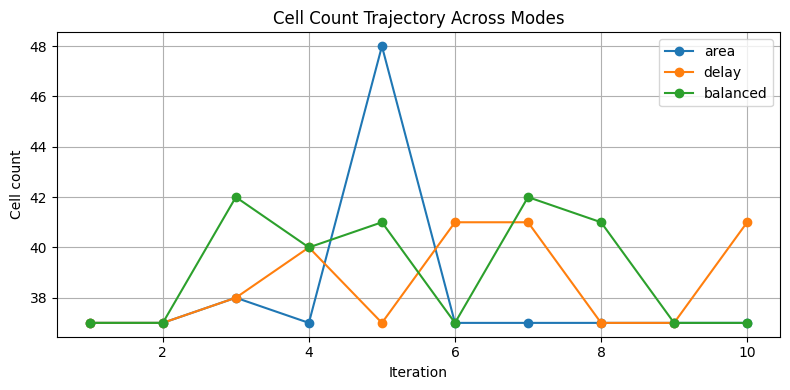

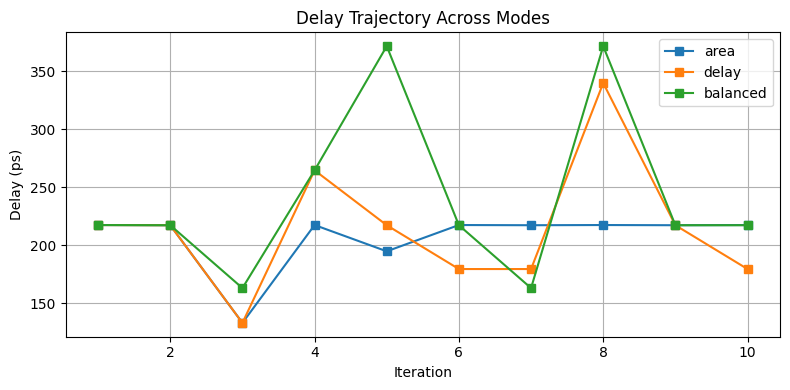

In [90]:
import json
import matplotlib.pyplot as plt

modes = ["area", "delay", "balanced"]

plt.figure(figsize=(8, 4))
for mode in modes:
    with open(f"optimization_log_{mode}.json", "r", encoding="utf-8") as f:
        log = json.load(f)
    iters = [r["iteration"] for r in log["iterations"]]
    cells = [r["ppa"]["cell_count"] for r in log["iterations"]]
    plt.plot(iters, cells, marker="o", label=mode)

plt.xlabel("Iteration")
plt.ylabel("Cell count")
plt.title("Cell Count Trajectory Across Modes")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("cells_compare_all_modes.pdf")
plt.show()

plt.figure(figsize=(8, 4))
for mode in modes:
    with open(f"optimization_log_{mode}.json", "r", encoding="utf-8") as f:
        log = json.load(f)
    iters = [r["iteration"] for r in log["iterations"]]
    delays = [r["ppa"]["logic_levels"] for r in log["iterations"]]
    plt.plot(iters, delays, marker="s", label=mode)

plt.xlabel("Iteration")
plt.ylabel("Delay (ps)")
plt.title("Delay Trajectory Across Modes")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("delay_compare_all_modes.pdf")
plt.show()

In [92]:
import os
from openai import OpenAI

api_key = os.getenv("OPENAI_API_KEY", "").strip()
if not api_key:
    raise ValueError("OPENAI_API_KEY is not set.")

client = OpenAI(api_key=api_key)

def read_file(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

# 把这里改成你实际跑出来的 best PPA
ppa_data = {
    "area": {
        "cells": 37,
        "delay_ps": 217.55,
        "area_um2": 69.426
    },
    "delay": {
        "cells": 38,
        "delay_ps": 133.24,
        "area_um2": 63.574
    },
    "balanced": {
        "cells": 37,
        "delay_ps": 217.38,
        "area_um2": 69.426
    }
}

verilog_data = {
    "area": read_file("best_adder_area.v"),
    "delay": read_file("best_adder_delay.v"),
    "balanced": read_file("best_adder_balanced.v"),
}

system_prompt = """You are an expert digital IC designer and technical report writer.
Analyze Verilog adder designs discovered by synthesis-guided optimization.

For each design, explain:
1. What adder architecture or hybrid architecture it represents;
2. Why this structure may reduce area or cell count compared to a Ripple Carry Adder;
3. The trade-offs in delay, logic depth, and fanout;
4. How it compares to Kogge-Stone, Brent-Kung, and Carry Select adders.

Write clearly, technically, and in report style.
Do not use markdown code fences.
"""

def analyze_design(mode, verilog_code, ppa):
    user_prompt = f"""
Analyze this optimized adder design.

Mode: {mode}
PPA:
- Cell count: {ppa['cells']}
- Delay (ps): {ppa['delay_ps']}
- Area (um^2): {ppa['area_um2']}

Verilog:
{verilog_code}

Please write:
- A short architecture identification title
- A 1-paragraph explanation of the architecture
- A 1-paragraph explanation of why it helps area/cell count versus RCA
- A 1-paragraph discussion of delay/fanout trade-offs
- A 1-paragraph comparison with Kogge-Stone, Brent-Kung, and Carry Select
"""
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0.2,
    )
    return response.choices[0].message.content.strip()

report_sections = []

for mode in ["area", "delay", "balanced"]:
    analysis = analyze_design(mode, verilog_data[mode], ppa_data[mode])
    section = f"""# {mode.capitalize()} Mode Best Design

PPA:
- Cell count: {ppa_data[mode]['cells']}
- Delay (ps): {ppa_data[mode]['delay_ps']}
- Area (um^2): {ppa_data[mode]['area_um2']}

{analysis}
"""
    report_sections.append(section)

full_report = "\n\n".join(report_sections)

with open("step6_report.md", "w", encoding="utf-8") as f:
    f.write(full_report)

print(full_report)
print("\nSaved to step6_report.md")

# Area Mode Best Design

PPA:
- Cell count: 37
- Delay (ps): 217.55
- Area (um^2): 69.426

Ripple Carry Adder (RCA) Architecture

The provided Verilog code represents a basic Ripple Carry Adder (RCA) architecture for an 8-bit addition operation. This design uses a series of full adders (FAs) connected in sequence, where the carry-out from each adder is fed into the carry-in of the next. This straightforward and linear structure is characterized by its simplicity and ease of implementation, making it a common choice for small bit-width additions.

The RCA architecture is inherently area-efficient due to its minimalistic design, which consists of only the necessary components to perform addition. Each bit addition requires a single full adder, and the design does not incorporate any additional logic for carry prediction or parallel processing, which keeps the cell count low. This simplicity directly translates to a reduced area footprint compared to more complex adder architectures that 

In [95]:
!iverilog -o opt_sim best_adder.v best_adder_tb.v
!vvp opt_sim

@@@PASS


In [105]:
!yosys -s equiv_check.ys


 /----------------------------------------------------------------------------\
 |                                                                            |
 |  yosys -- Yosys Open SYnthesis Suite                                       |
 |                                                                            |
 |  Copyright (C) 2012 - 2019  Clifford Wolf <clifford@clifford.at>           |
 |                                                                            |
 |  Permission to use, copy, modify, and/or distribute this software for any  |
 |  purpose with or without fee is hereby granted, provided that the above    |
 |  copyright notice and this permission notice appear in all copies.         |
 |                                                                            |
 |  THE SOFTWARE IS PROVIDED "AS IS" AND THE AUTHOR DISCLAIMS ALL WARRANTIES  |
 |  WITH REGARD TO THIS SOFTWARE INCLUDING ALL IMPLIED WARRANTIES OF          |
 |  MERCHANTABILITY AND FITNESS. IN NO 

In [129]:
!python optimize_adder.py --baseline RCA8/RCA8_generated.v --mode balanced --out rca_bal

流式输出内容被截断，只能显示最后 5000 行内容。
 Yosys 0.9 (git sha1 1979e0b)


-- Executing script file `tmp_synth.ys' --

1. Executing Verilog-2005 frontend: rca_bal/balanced_candidate_2.v
Parsing Verilog input from `rca_bal/balanced_candidate_2.v' to AST representation.
Generating RTLIL representation for module `\CLA4'.
Generating RTLIL representation for module `\RCA8'.
Successfully finished Verilog frontend.

2. Executing HIERARCHY pass (managing design hierarchy).

2.1. Analyzing design hierarchy..
Top module:  \RCA8
Used module:     \CLA4

2.2. Analyzing design hierarchy..
Top module:  \RCA8
Used module:     \CLA4
Removed 0 unused modules.

3. Executing FLATTEN pass (flatten design).
Using template CLA4 for cells of type CLA4.
<suppressed ~2 debug messages>
No more expansions possible.
Deleting now unused module CLA4.

4. Executing PROC pass (convert processes to netlists).

4.1. Executing PROC_CLEAN pass (remove empty switches from decision trees).
Cleaned up 0 empty switches.

4.2. Executing PROC

In [134]:
!python optimize_adder.py --baseline CLA8/CLA8_generated.v --mode delay --out cla_delay

流式输出内容被截断，只能显示最后 5000 行内容。
Performed a total of 0 changes.

5.5. Executing OPT_MERGE pass (detect identical cells).
Finding identical cells in module `\CLA8'.
Removed a total of 0 cells.

5.6. Executing OPT_RMDFF pass (remove dff with constant values).

5.7. Executing OPT_CLEAN pass (remove unused cells and wires).
Finding unused cells or wires in module \CLA8..
Removed 3 unused cells and 50 unused wires.
<suppressed ~5 debug messages>

5.8. Executing OPT_EXPR pass (perform const folding).
Optimizing module CLA8.

5.9. Rerunning OPT passes. (Maybe there is more to do..)

5.10. Executing OPT_MUXTREE pass (detect dead branches in mux trees).
Running muxtree optimizer on module \CLA8..
  Creating internal representation of mux trees.
  No muxes found in this module.
Removed 0 multiplexer ports.

5.11. Executing OPT_REDUCE pass (consolidate $*mux and $reduce_* inputs).
  Optimizing cells in module \CLA8.
Performed a total of 0 changes.

5.12. Executing OPT_MERGE pass (detect identical cell

In [139]:
!python collect_results.py cla_delay rca_bal

| Starting Architecture | Optimization Mode | Final Cells | Final Logic Delay | Final Area (um²) | Architecture Identified |
|---|---|---|---|---|---|
| CLA8 | Delay | 42 | 168.33 | 73.948 | CLA |
| RCA8 | Balanced | 44 | 216.09 | 57.722 | RCA |

Saved to final_summary_table.csv


In [140]:
!zip -r all_results.zip .

updating: .config/ (stored 0%)
updating: .config/.last_survey_prompt.yaml (stored 0%)
updating: .config/logs/ (stored 0%)
updating: .config/logs/2026.04.02/ (stored 0%)
updating: .config/logs/2026.04.02/13.31.07.077226.log (deflated 56%)
updating: .config/logs/2026.04.02/13.30.52.812826.log (deflated 58%)
updating: .config/logs/2026.04.02/13.30.51.422062.log (deflated 87%)
updating: .config/logs/2026.04.02/13.31.06.236912.log (deflated 57%)
updating: .config/logs/2026.04.02/13.30.40.372331.log (deflated 58%)
updating: .config/logs/2026.04.02/13.30.17.544197.log (deflated 92%)
updating: .config/configurations/ (stored 0%)
updating: .config/configurations/config_default (deflated 15%)
updating: .config/gce (stored 0%)
updating: .config/default_configs.db (deflated 98%)
updating: .config/active_config (stored 0%)
updating: .config/.last_update_check.json (deflated 22%)
updating: .config/.last_opt_in_prompt.yaml (stored 0%)
updating: .config/config_sentinel (stored 0%)
updating: .config/hi

In [137]:
!iverilog -o opt_sim cla_delay/best_adder.v cla_delay/best_adder_tb.v
!vvp opt_sim

@@@PASS a=00 b=00 | result=000
@@@PASS a=01 b=01 | result=002
@@@PASS a=0f b=01 | result=010
@@@PASS a=0a b=05 | result=00f
@@@PASS a=0f b=0f | result=01e
@@@PASS a=10 b=10 | result=020
@@@PASS a=55 b=aa | result=0ff
@@@PASS a=7f b=01 | result=080
@@@PASS a=80 b=80 | result=100
@@@PASS a=ff b=00 | result=0ff
@@@PASS a=ff b=01 | result=100
@@@PASS a=ff b=ff | result=1fe
@@@PASS a=00 b=00 | result=000
@@@PASS a=00 b=01 | result=001
@@@PASS a=00 b=02 | result=002
@@@PASS a=00 b=03 | result=003
@@@PASS a=00 b=04 | result=004
@@@PASS a=00 b=05 | result=005
@@@PASS a=00 b=06 | result=006
@@@PASS a=00 b=07 | result=007
@@@PASS a=00 b=08 | result=008
@@@PASS a=00 b=09 | result=009
@@@PASS a=00 b=0a | result=00a
@@@PASS a=00 b=0b | result=00b
@@@PASS a=00 b=0c | result=00c
@@@PASS a=00 b=0d | result=00d
@@@PASS a=00 b=0e | result=00e
@@@PASS a=00 b=0f | result=00f
@@@PASS a=01 b=00 | result=001
@@@PASS a=01 b=01 | result=002
@@@PASS a=01 b=02 | result=003
@@@PASS a=01 b=03 | result=004
@@@PASS 

In [138]:
!yosys -s equiv_check_cla.ys


 /----------------------------------------------------------------------------\
 |                                                                            |
 |  yosys -- Yosys Open SYnthesis Suite                                       |
 |                                                                            |
 |  Copyright (C) 2012 - 2019  Clifford Wolf <clifford@clifford.at>           |
 |                                                                            |
 |  Permission to use, copy, modify, and/or distribute this software for any  |
 |  purpose with or without fee is hereby granted, provided that the above    |
 |  copyright notice and this permission notice appear in all copies.         |
 |                                                                            |
 |  THE SOFTWARE IS PROVIDED "AS IS" AND THE AUTHOR DISCLAIMS ALL WARRANTIES  |
 |  WITH REGARD TO THIS SOFTWARE INCLUDING ALL IMPLIED WARRANTIES OF          |
 |  MERCHANTABILITY AND FITNESS. IN NO 